**VERSION v0**: I optimized the original code so that it runs in much less time, while preserving the general calculations that are performed and the optimization with Powell that was chosen.

### 1. Initialization and fitting parameters

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation_cons as sim
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm


In [23]:
## ----- FITTING PARAMETERS ----- ##

# folder and name of final results file
folder = "results/v0_results/"

# cost function from eq. 11 (options: "C1"=radiometer, "C2"=1)
CF = "C1"

# angular mask [degrees] (options: "1F","5F" or None)
deg = None
if deg==None:  path_nearby = None
else:  path_nearby = (pm.path_data+"nearby_satellites/nearby_satellite_close_angle_"+deg+".p")

# thermal mask [kelvin] (options: 100,50,25 or None)
temp = None

# temporal mask [seconds] (options: 775-1000, 2200-2400, 5500-6200 or None)
t_slice = [None,None]

# threshold pixel mask (options: 2,5,7 or None)
pix = None


In [25]:
pm.show_parameters(CF, deg, temp, pix, t_slice)
print()
fname = pm.my_name(folder, CF, deg, temp, pix, t_slice)
print("File with final alpha parameters will be '{}'".format(fname))

Block: 1551055211
Frequency range: 1100 - 1350 MHz
Time range: inf - inf seconds
The cost function denominator will be: radiometer equation (C1).
Masking: None

File with final alpha parameters will be 'results/v0_results/nomask_C1.p'


### 2. Setting up the simulation

We initialize the SatelliteSimulation object, which will store the information. We also set up the functions that are necessary for the optimizations.

Getting catalog...
Number of signals in satellite catalog:  21
Getting beam response (2GB) ...
Number of constellations present:  6
Getting temperature factors for each signal...
Starting index of constellations:  [ 0  4  9 13 18 20]
Getting observational data...


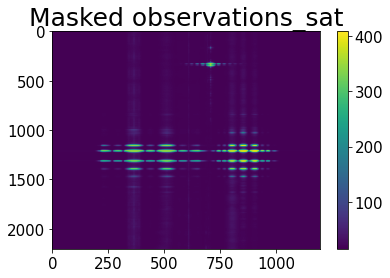

Size of arrays:
 - Frequency:  (1199,)
 - Time:  (2203,)
 - Size of simulated Tb_factors:  (21, 1199)
 - Size of simulated sat_beam:  (6, 1199, 2203)
 - Size of observations:  (1199, 2203)


In [26]:
# initializing the simulation
sat = sim.SatelliteSimulation(
    block=str(pm.block),
    use_data=True,
    path_data=pm.path_data,
    path_beam=pm.path_data,
    survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
    path_catalog="Satellite_Catalogue/satellite_constellation_catalog.csv",
    beam_model=pm.beam_model,
    freq_range=[pm.fs, pm.fe],
    freq_slice=[pm.fs_slice, pm.fe_slice],
    time_slice=t_slice,
    include_cons=pm.include_cons,
    verbose=True,
)

# applying mask
sat.create_mask(path_nearby, temp, pix, verbose=True)


In [27]:
# defining the cost function

if CF=="C1":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=obs (case C1). '''
        sat.execute(alphas)
        CF = np.sum( ((sat.observations_sat-sat.simulation) / sat.observations)**2 )
        print(CF,end="\t")
        return CF

elif CF=="C2":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=1 (case C2). '''
        sat.execute(alphas)
        CF = np.sum( (sat.observations_sat-sat.simulation)**2 )
        print(CF,end="\t")
        return CF


In [28]:
# defining initial values and boundary conditions
alphas0 = np.zeros(len(sat.catalog))
bnds = [(0.0,None) for _ in range(len(sat.catalog))]

# testing cost function at initial value
_ = Cost_Function(alphas0)


117746.14337149153	

### 3. Running the optimization

We now run the optimization with the functions and parameters defined above.

In [29]:
# running the optimization
print("Running optimization...")
start = time.perf_counter()
signal_PL = opt.minimize(
    fun = Cost_Function,
    x0 = alphas0,
    method = "Powell",
    bounds = bnds,
    tol = 1e-6,
    options={"maxiter":20, "disp":True},
)
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Running optimization...
117746.14337149153	116774.87631436795	115910.58971020087	115118.55441264312	114916.87541833463	115789.15110476353	114875.38190723592	114850.16132558048	114846.9744588028	114846.42244161051	114846.29449992957	114846.29438933694	114846.29436159862	114846.29436159835	114846.29436160957	114580.4723813657	116712.58875614354	114449.31712390271	114451.20194671136	114445.17534582881	114445.17689052889	114445.17534443577	114445.17534401521	114445.17534401563	114445.17534401565	115566.87189572533	133455.5247045941	113404.36716104769	113585.65641825816	113268.55535192252	113371.29503014452	113249.90358670981	113249.83102999652	113249.82187044948	113249.82185728829	113249.82185728438	113249.8218572863	108426.8326818889	270320.0591388687	93600.82285178125	94896.146008761	93550.69382152664	93524.4999406773	93524.2671387553	93524.26521142454	93524.26520607318	93524.26520608945	93524.26520610058	677610.1148257144	2828129.56054407	275295.1182627146	258246.07162961015	149479.2875

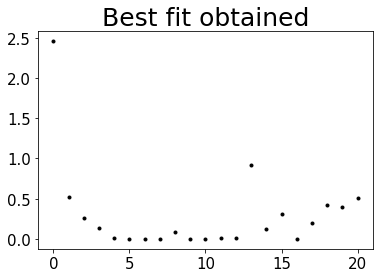

In [30]:
# saving best fit values
alphas_BF = signal_PL.x

# plotting values just to check
plt.plot(alphas_BF,"k.")
plt.title("Best fit obtained")
plt.show()

In [1]:
# saving information in the file
data_info = {
    "initial" : alphas0,
    "CF" : CF,
    "mask_degree" : deg, 
    "mask_temperature" : temp, 
    "mask_pix" : pix, 
    "time_slice" : t_slice,
    "frequency_slice" : [pm.fs_slice, pm.fe_slice], 
    "best-fit" : alphas_BF,
}

print(f"Information saved in file '{fname}'.")
pickle.dump( data_info, open(fname,"wb") )


NameError: name 'alphas0' is not defined